Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset:
  Label                                            Message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Accuracy:
0.9443946188340807

Precision:
0.9680851063829787

Recall:
0.6066666666666667


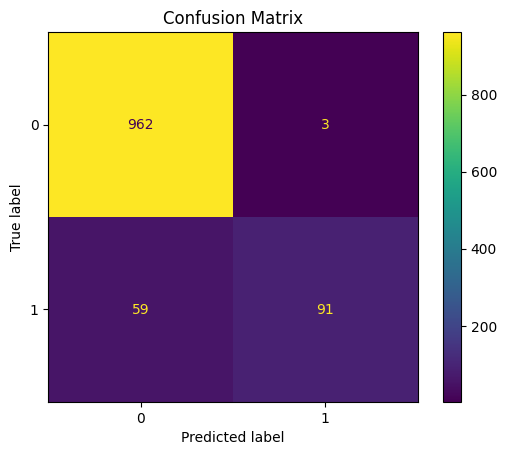

In [3]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score
)

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/internship_csv_files/spam.csv', encoding='latin-1')

# Keep only required columns
df = df[['v1', 'v2']]

# Rename columns
df.columns = ['Label', 'Message']

# Display dataset
print("Dataset:")
print(df.head())

# Encode labels
df['Label'] = df['Label'].map({
    'ham': 0,
    'spam': 1
})

# Features and target
X = df['Message']
y = df['Label']

# Convert text to numerical features
vectorizer = TfidfVectorizer(stop_words='english')

X_vectorized = vectorizer.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
model = LogisticRegression()

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:")
print(accuracy)

# Precision
precision = precision_score(y_test, y_pred)

print("\nPrecision:")
print(precision)

# Recall
recall = recall_score(y_test, y_pred)

print("\nRecall:")
print(recall)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")

plt.show()